# Week 7
The following notebook provides a cleaned version of data I want to use for the midterm.  I identify neighborhoods in the top quratile of Ellis Act filings per number of RSOs per neighborhood.  I create a loop mapping top quartile neighborhoods.

## Upload and join data

In [1]:
# Step 1: Importing Required Libraries
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install tabulate
from tabulate import tabulate

In [2]:
# Step 2: Load LA Neighborhood Boundaries
neighborhoods_path = "LA_Times_Neighborhood_Boundaries.geojson"  # Update with the correct file path

# Check if the file exists before proceeding
try:
    neighborhoods = gpd.read_file(neighborhoods_path)
    neighborhoods = neighborhoods.to_crs(epsg=4326)  # Ensure consistent CRS
    print("Neighborhoods data loaded successfully.")
except Exception as e:
    print(f"Error loading neighborhoods data: {e}")

# Print the first few rows to verify the data
print(neighborhoods.head())

Neighborhoods data loaded successfully.
   OBJECTID                    name  \
0         1         Adams-Normandie   
1         2                  Arleta   
2         3       Arlington Heights   
3         4         Atwater Village   
4         5  Baldwin Hills/Crenshaw   

                                            geometry  
0  POLYGON ((-118.30069 34.03731, -118.30388 34.0...  
1  POLYGON ((-118.44255 34.26412, -118.4424 34.26...  
2  POLYGON ((-118.31862 34.05306, -118.31673 34.0...  
3  MULTIPOLYGON (((-118.27886 34.15321, -118.2788...  
4  POLYGON ((-118.36102 34.02532, -118.36026 34.0...  


In [3]:
# Step 3: Load RSO Data
rso_data_path = 'RSO_Total_Geocoded_Final.csv'  # Replace with actual file path

# Load RSO data and ensure it contains the expected columns
try:
    rso_data = pd.read_csv(rso_data_path)
    rso_gdf = gpd.GeoDataFrame(rso_data, geometry=gpd.points_from_xy(rso_data.Longitude, rso_data.Latitude), crs='EPSG:4326')
    print("RSO data loaded successfully.")
except Exception as e:
    print(f"Error loading RSO data: {e}")

RSO data loaded successfully.


In [4]:
# Step 4: Load Ellis Act Filings Data
ellis_data_path = 'Ellis Act.csv'  # Replace with actual file path

# Load Ellis Act data and ensure it contains the expected columns
try:
    ellis_data = pd.read_csv(ellis_data_path)
    ellis_gdf = gpd.GeoDataFrame(ellis_data, geometry=gpd.points_from_xy(ellis_data.Longitude, ellis_data.Latitude), crs='EPSG:4326')
    print("Ellis Act data loaded successfully.")
except Exception as e:
    print(f"Error loading Ellis Act data: {e}")

Ellis Act data loaded successfully.


In [5]:
# Step 5: Spatial Join - Assign RSO and Ellis Act filings to neighborhoods
try:
    rso_neighborhoods = gpd.sjoin(rso_gdf, neighborhoods, how='left', predicate='within')
    ellis_neighborhoods = gpd.sjoin(ellis_gdf, neighborhoods, how='left', predicate='within')
    print("Spatial join for RSO and Ellis Act data completed.")
except Exception as e:
    print(f"Error performing spatial join: {e}")


Spatial join for RSO and Ellis Act data completed.


## Calculate the top quartile
Calculate neighborhoods in the top quartile of RSO removals.

In [6]:
# Step 6: Calculate and Print Total RSO and Ellis Act Withdrawals
ellis_counts = ellis_neighborhoods['Units Withdrawn'].sum()
rso_units = rso_neighborhoods['RSO Units'].sum()
withdrawal_percentage = (ellis_counts / rso_units) * 100

print(f"Total Ellis Act Units Withdrawn: {ellis_counts}")
print(f"Total RSO Units: {rso_units}")
print(f"Percentage of RSO Units Withdrawn via Ellis Act: {withdrawal_percentage:.2f}%")

Total Ellis Act Units Withdrawn: 13455.0
Total RSO Units: 686463
Percentage of RSO Units Withdrawn via Ellis Act: 1.96%


In [7]:
# Step 6 (Revised): Calculate Withdrawal Percentage by Neighborhood

# Group by neighborhood and sum the 'Units Withdrawn' and 'RSO Units'
ellis_counts = ellis_neighborhoods.groupby('name')['Units Withdrawn'].sum()
rso_units = rso_neighborhoods.groupby('name')['RSO Units'].sum()

# Filter out neighborhoods with fewer than 275 RSO units
rso_units = rso_units[rso_units >= 275]  # Keep only neighborhoods with RSO units >= 275

# Ensure both ellis_counts and rso_units only include the same neighborhoods
common_neighborhoods = rso_units.index.intersection(ellis_counts.index)
rso_units = rso_units[common_neighborhoods]
ellis_counts = ellis_counts[common_neighborhoods]

# Calculate withdrawal percentage
withdrawal_percentage = (ellis_counts / rso_units) * 100
withdrawal_percentage = withdrawal_percentage.fillna(0)  # Replace NaN with 0 for neighborhoods without Ellis Act filings

# Print the result
print("Withdrawal percentages by neighborhood:")
print(withdrawal_percentage)


Withdrawal percentages by neighborhood:
name
Adams-Normandie           2.118227
Arlington Heights         1.447178
Atwater Village           1.297371
Baldwin Hills/Crenshaw    0.618141
Bel-Air                   2.031603
                            ...   
Westwood                  2.477525
Wilmington                0.250696
Windsor Square            1.192053
Winnetka                  0.330106
Woodland Hills            0.414723
Length: 102, dtype: float64


In [8]:
# Step 7: Merge Withdrawal Percentage Back to Neighborhoods GeoDataFrame
neighborhoods['withdrawal_percentage'] = neighborhoods['name'].map(withdrawal_percentage)


In [9]:
# Step 8: Identify Top Quartile Neighborhoods
top_quartile_threshold = withdrawal_percentage.quantile(0.75)
top_quartile_neighborhoods = neighborhoods[neighborhoods['withdrawal_percentage'] >= top_quartile_threshold]


In [10]:
# Step 9: Display Top Quartile Neighborhoods in a Table
withdrawal_percentage_df = withdrawal_percentage.reset_index()
withdrawal_percentage_df.columns = ['Neighborhood', 'Withdrawal Percentage']
top_quartile_threshold = withdrawal_percentage_df['Withdrawal Percentage'].quantile(0.75)
top_quartile_df = withdrawal_percentage_df[withdrawal_percentage_df['Withdrawal Percentage'] >= top_quartile_threshold]
top_quartile_df = top_quartile_df.sort_values(by='Withdrawal Percentage', ascending=True)

# Format percentage values
top_quartile_df['Withdrawal Percentage'] = top_quartile_df['Withdrawal Percentage'].round(2)

# Print the table
print(tabulate(top_quartile_df, headers='keys', tablefmt='grid'))


+----+------------------------+-------------------------+
|    | Neighborhood           |   Withdrawal Percentage |
+====+========================+=========================+
| 58 | North Hollywood        |                    2.92 |
+----+------------------------+-------------------------+
| 65 | Pico-Union             |                    2.97 |
+----+------------------------+-------------------------+
| 35 | Harvard Heights        |                    3.01 |
+----+------------------------+-------------------------+
| 28 | Florence               |                    3.05 |
+----+------------------------+-------------------------+
| 92 | West Adams             |                    3.09 |
+----+------------------------+-------------------------+
| 52 | Mid-City               |                    3.16 |
+----+------------------------+-------------------------+
| 11 | Carthay                |                    3.16 |
+----+------------------------+-------------------------+
| 87 | Vermont

## Maps
Create maps and a loop of the top quartile neighborhoods.

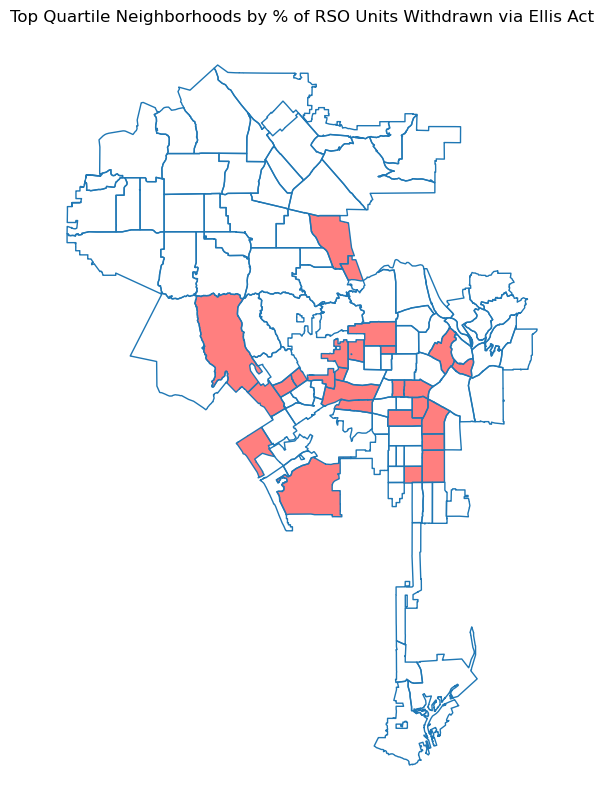

In [11]:
# Step 10: Plot Top Quartile Neighborhoods
fig, ax = plt.subplots(figsize=(10, 10))
neighborhoods.boundary.plot(ax=ax, linewidth=1)
top_quartile_neighborhoods.plot(ax=ax, color='red', alpha=0.5)
plt.title('Top Quartile Neighborhoods by % of RSO Units Withdrawn via Ellis Act')
ax.set_axis_off()
plt.show()

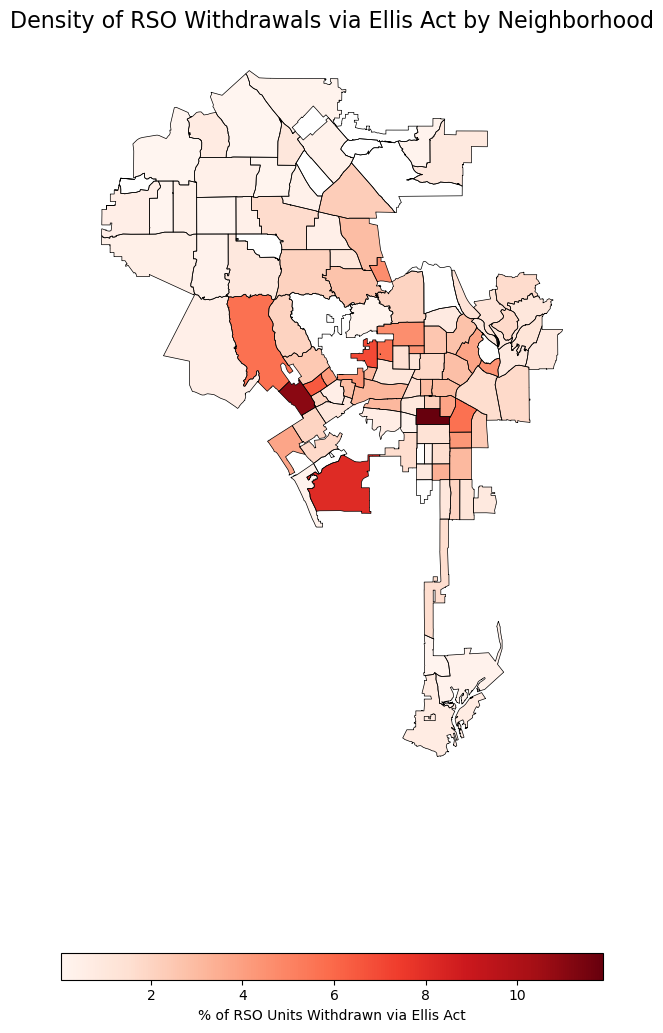

In [12]:
# Step 11: Density Map for RSO Withdrawals by Neighborhood
fig, ax = plt.subplots(figsize=(14, 14))  # Increase figure size for better visibility

# Plot the neighborhood boundary in black to create a border
neighborhoods.boundary.plot(ax=ax, linewidth=0.5, color="black")

# Use the 'Reds' colormap to achieve a light-to-dark red gradient
neighborhoods.plot(column='withdrawal_percentage', ax=ax, legend=True, cmap='Reds', 
                   legend_kwds={'label': "% of RSO Units Withdrawn via Ellis Act",
                                'orientation': "horizontal", 'shrink': 0.5})

plt.title('Density of RSO Withdrawals via Ellis Act by Neighborhood', fontsize=16)
ax.set_axis_off()  # Hide grid and axis labels
plt.show()

In [13]:
import folium
from folium import GeoJson

In [14]:
# Step 11: Density Map for RSO Withdrawals by Neighborhood
# Define a center point for the map
center_lat, center_lon = 34.0522, -118.2437  # Default: Los Angeles coordinates

# Create a folium map centered dynamically
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, 
               tiles="CartoDB positron",  # Light background for better contrast
               control_scale=True)

# Add a Title Overlay with a Short Description
title_html = '''
    <h3 align="center" style="font-size:16px"><b>RSO Withdrawals via Ellis Act by Neighborhood</b></h3>
    <p align="center" style="font-size:12px">This interactive map shows the percentage of Rent-Stabilized Ordinance (RSO) units withdrawn under the Ellis Act across Los Angeles neighborhoods. 
    Higher percentages indicate areas experiencing stronger displacement pressures.</p>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Ensure null values are replaced with zero for visualization consistency
neighborhoods['withdrawal_percentage'] = neighborhoods['withdrawal_percentage'].fillna(0)

# Add Choropleth Layer (Shades of Red), setting missing values to white
folium.Choropleth(
    geo_data=neighborhoods,  # Ensure `neighborhoods` is a GeoDataFrame
    name="RSO Withdrawal Percentage",
    data=neighborhoods,
    columns=["name", "withdrawal_percentage"],  # Ensure these columns exist
    key_on="feature.properties.name",
    fill_color="Reds",
    nan_fill_color="white",  # Set missing values to white instead of black
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="% of RSO Units Withdrawn via Ellis Act",
).add_to(m)

# Format tooltips to show percentage values with two decimal places and add a % sign
GeoJson(
    neighborhoods,
    name="Neighborhood Boundaries",
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 1.5,
        'fillOpacity': 0.5,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "withdrawal_percentage"], 
        aliases=["Neighborhood", "% of RSO Units Withdrawn"],
        localize=True,
        format_string="{:.2f}%"
    ),
).add_to(m)

# Add Layer Control
folium.LayerControl().add_to(m)

# Step 8: Save Map as HTML
map_path = "RSO_Withdrawals_LA_Neighborhoods.html"
m.save(map_path)

# Display the map
m


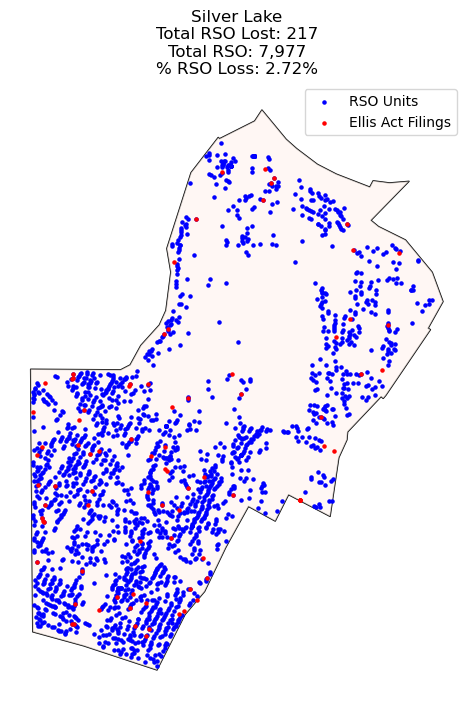

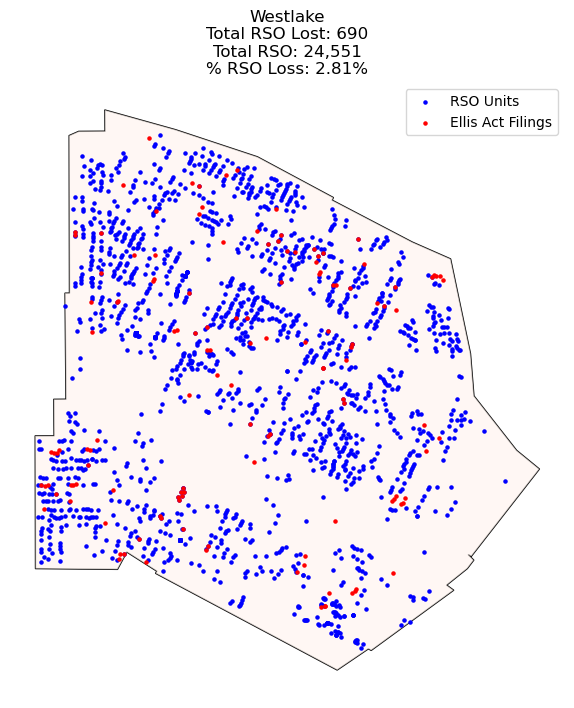

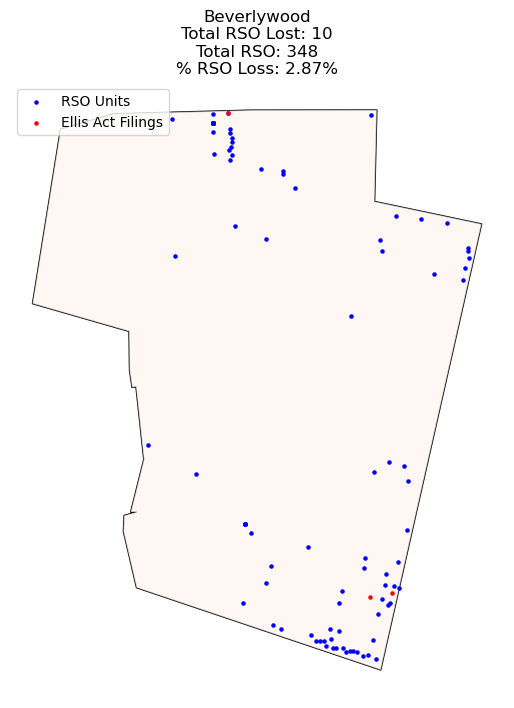

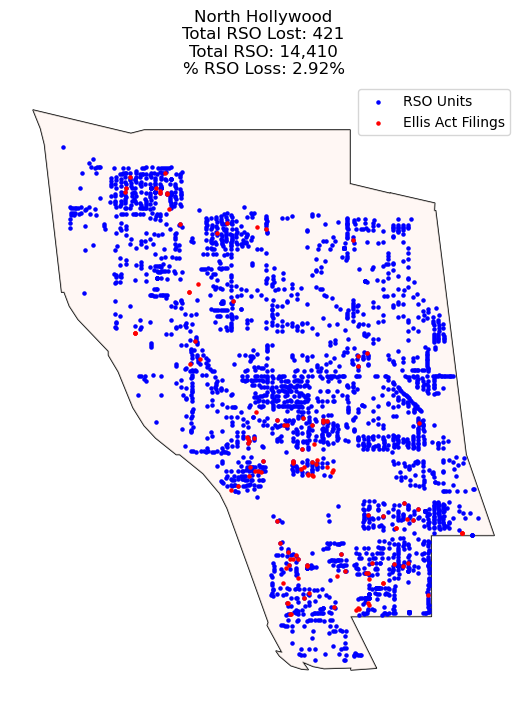

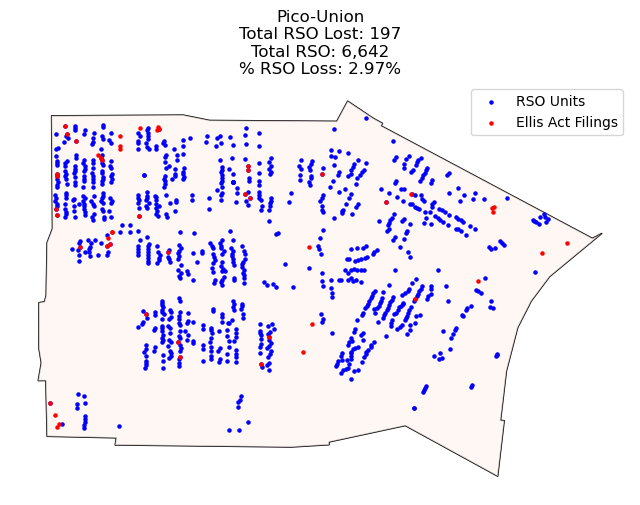

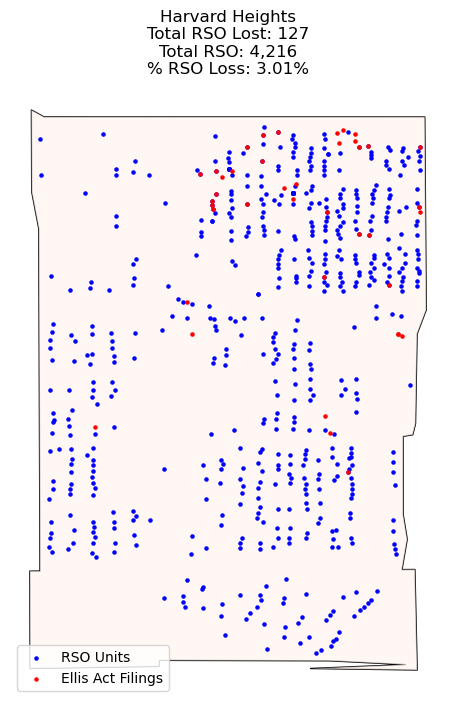

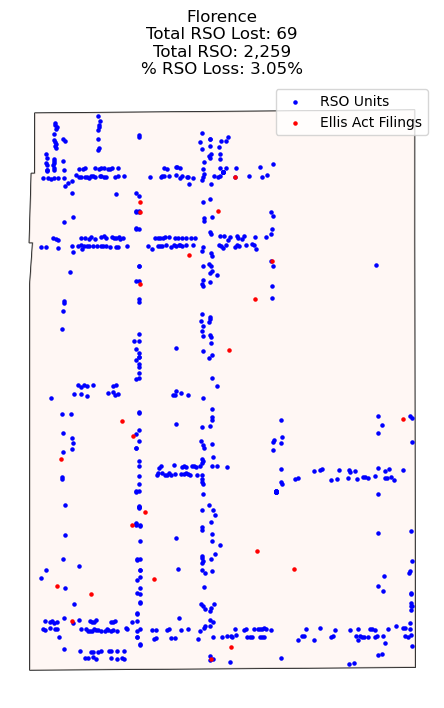

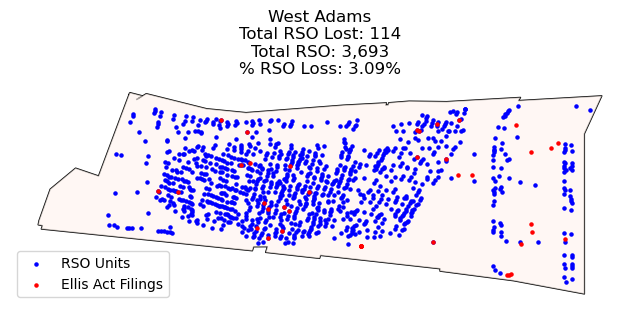

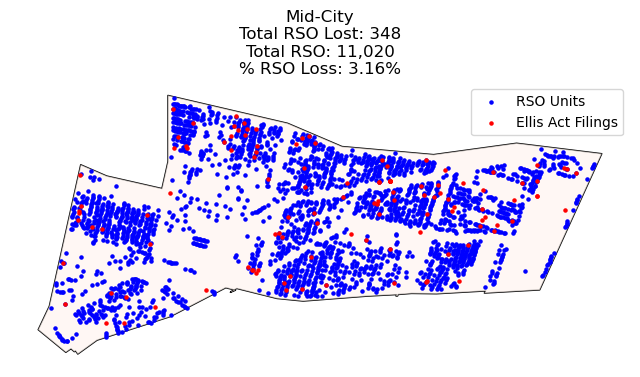

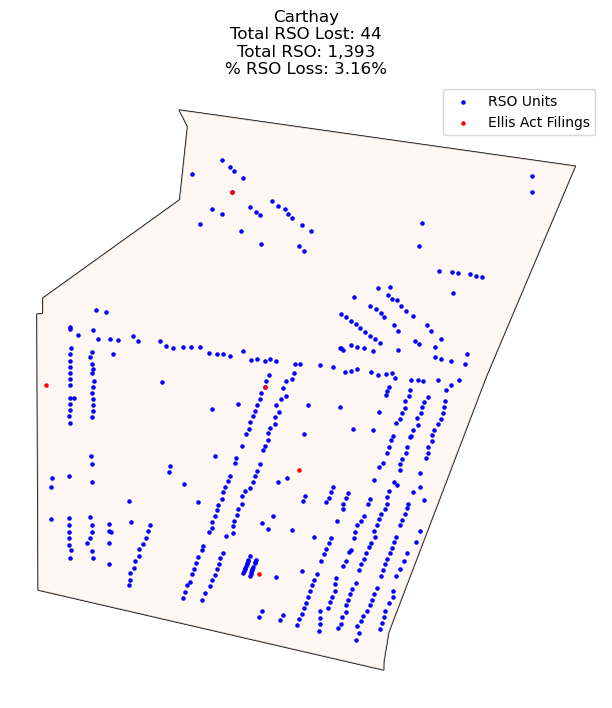

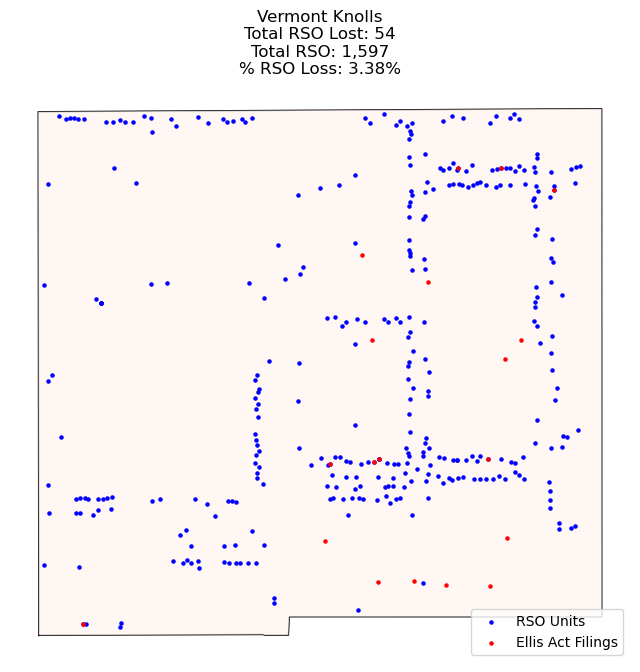

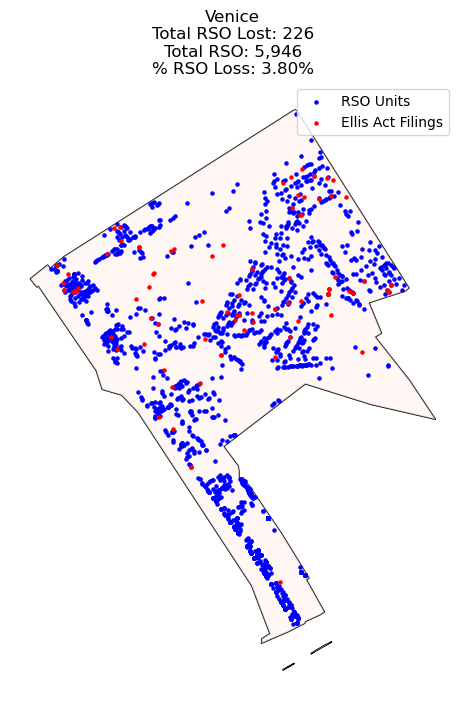

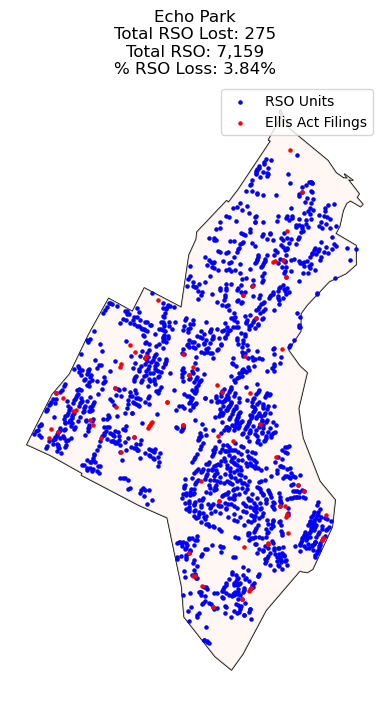

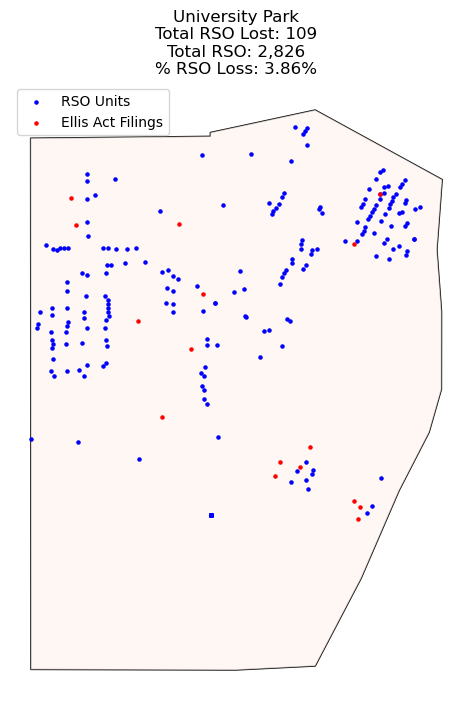

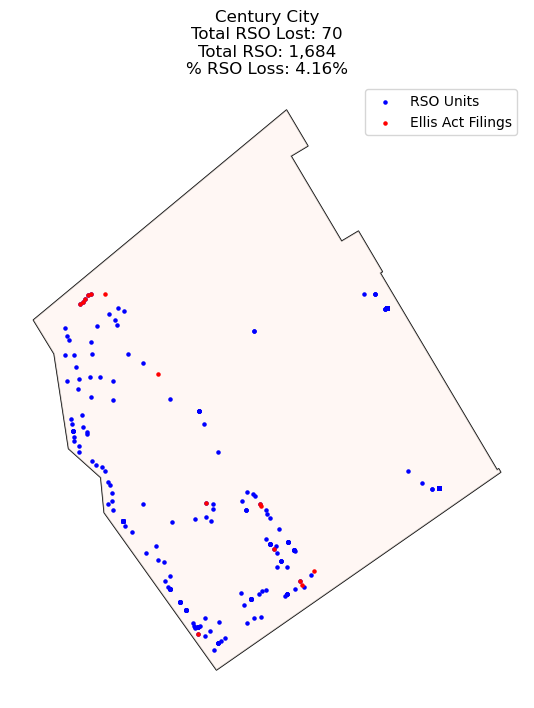

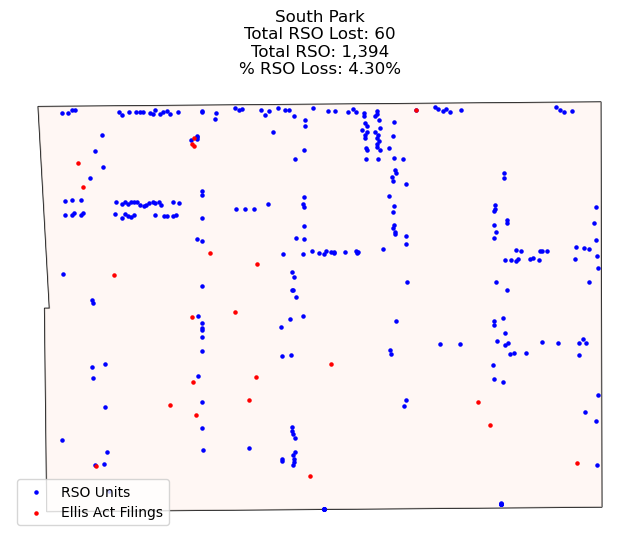

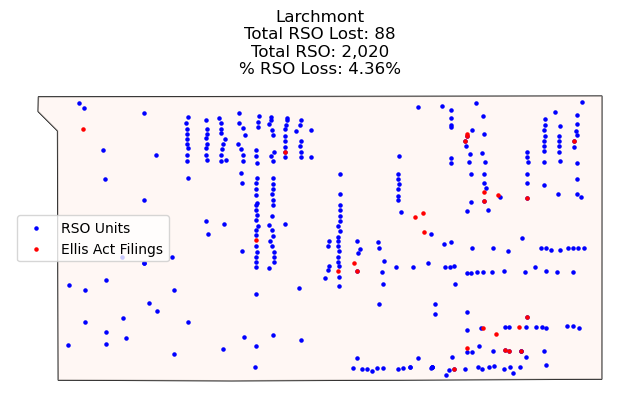

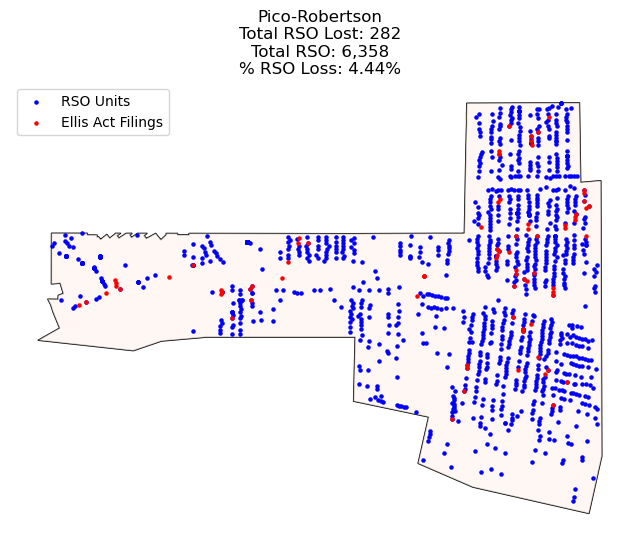

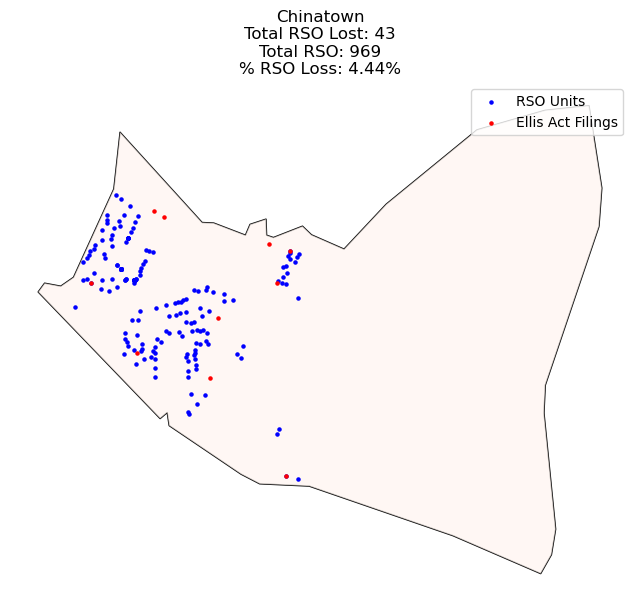

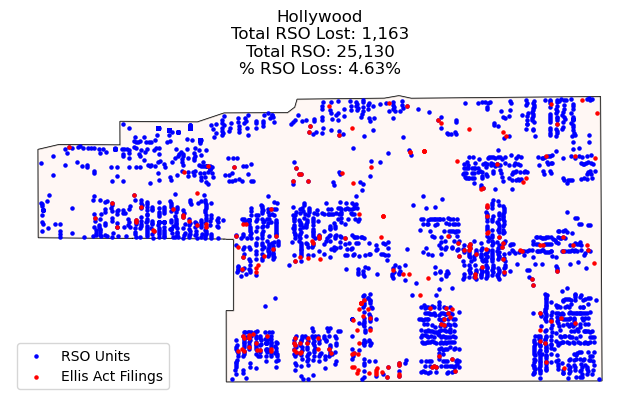

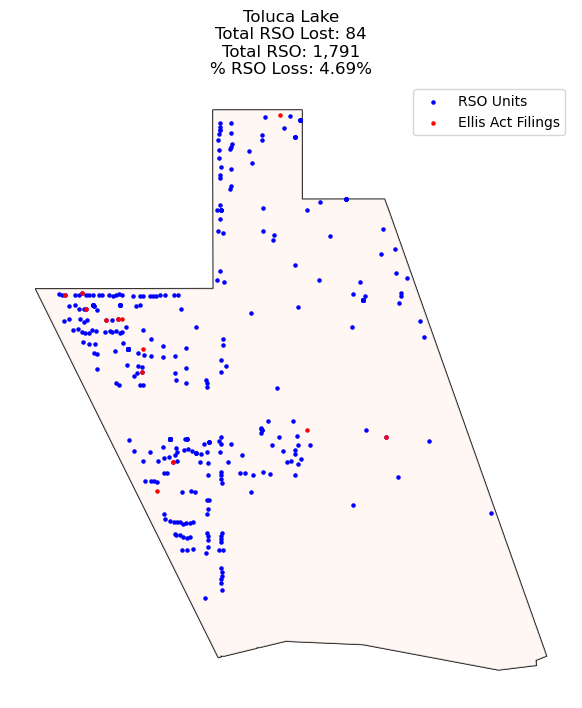

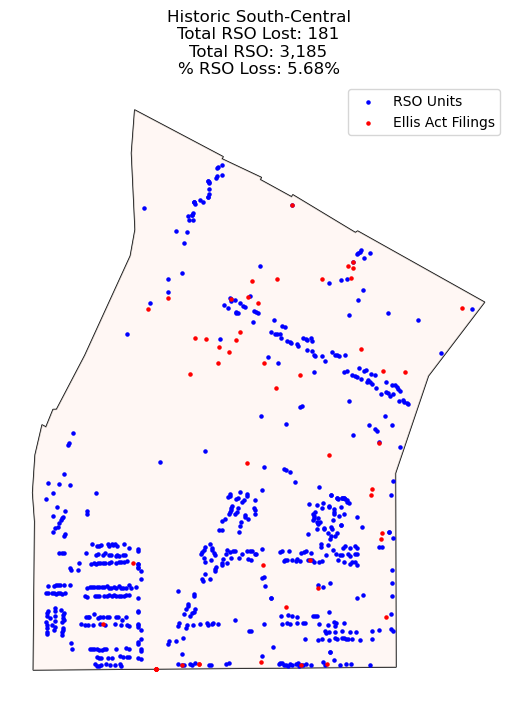

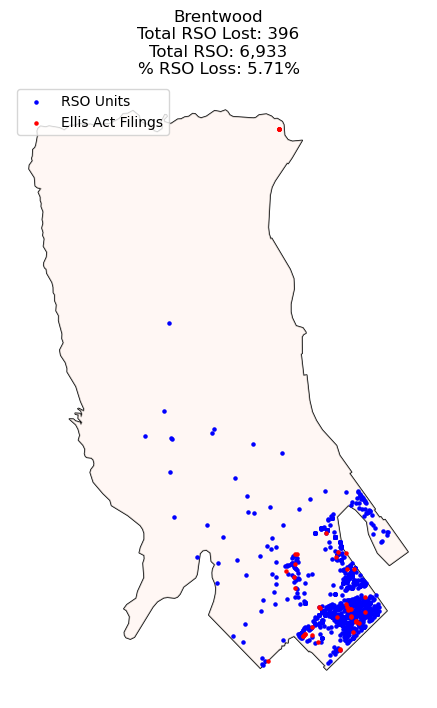

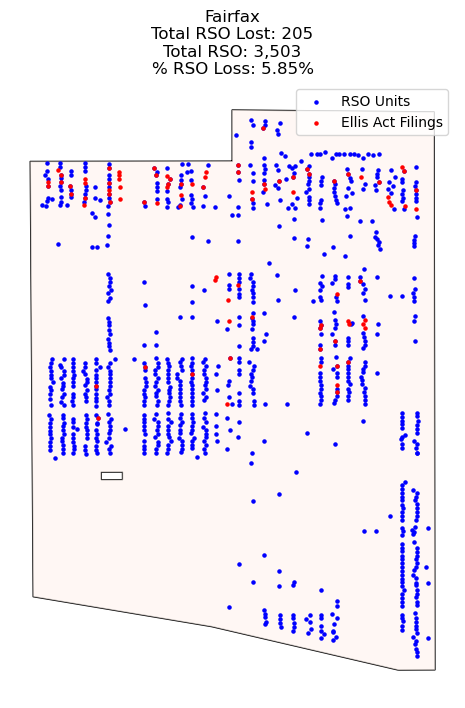

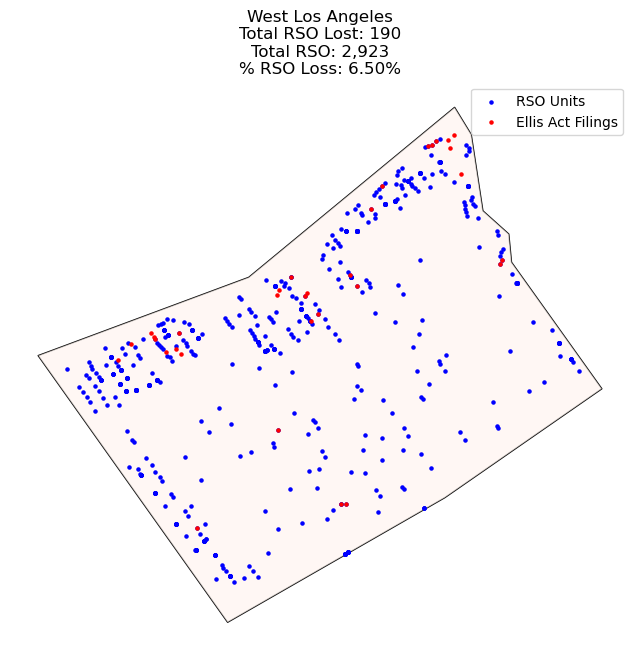

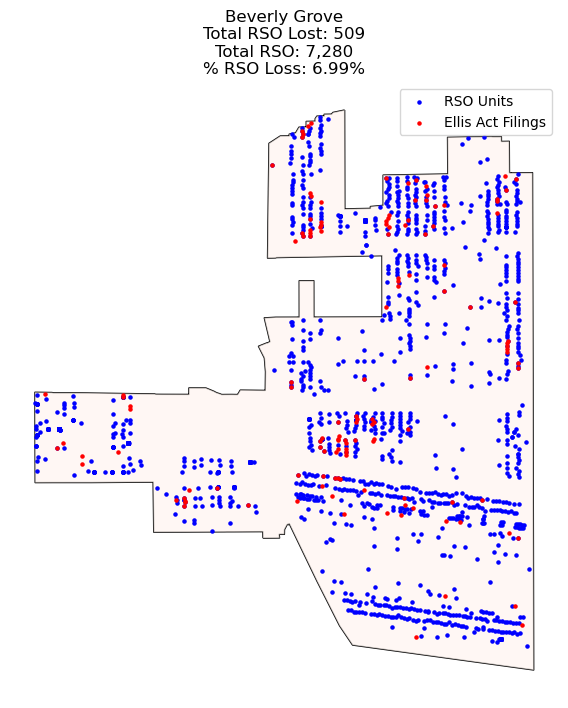

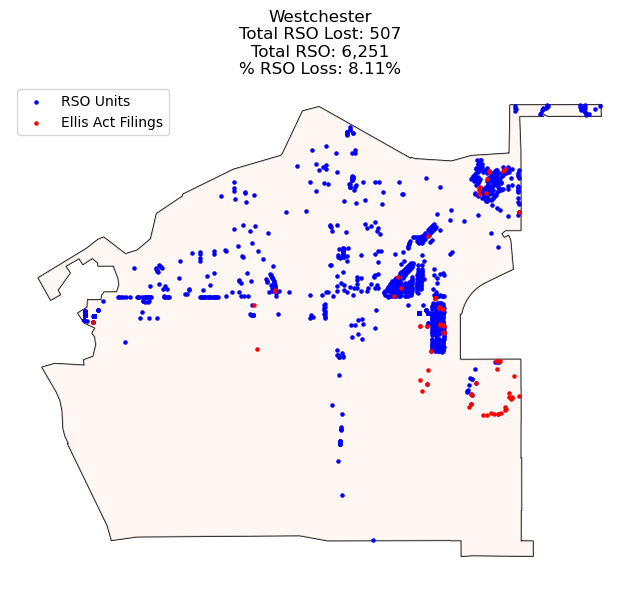

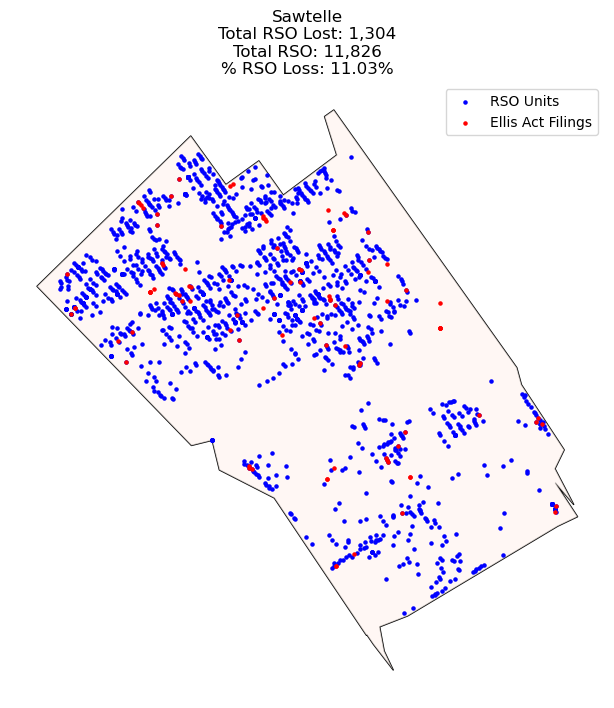

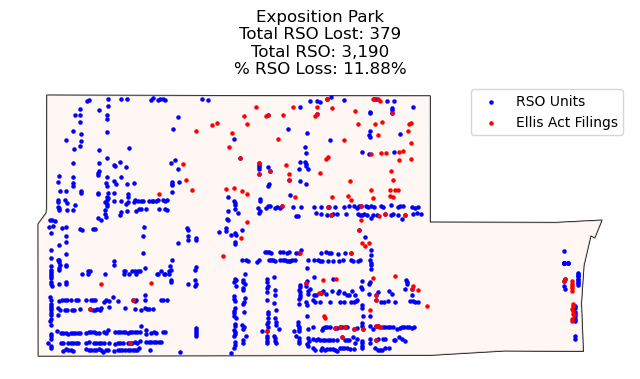

In [15]:
# Step 12: Quartile Assignment and Generating Detailed Maps for Top Quartile Neighborhoods
if "quartile" not in neighborhoods.columns:
    quartiles = np.percentile(neighborhoods["withdrawal_percentage"].dropna(), [25, 50, 75])
    quartiles = np.sort(quartiles)  # Ensure quartiles are in increasing order
    labels = ["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"]

    neighborhoods.loc[:, "quartile"] = pd.cut(neighborhoods["withdrawal_percentage"],
                                              bins=[-np.inf, quartiles[0], quartiles[1], quartiles[2], np.inf],
                                              labels=labels)

# Filter top quartile neighborhoods and sort them
top_quartile_neighborhoods = neighborhoods[neighborhoods["quartile"] == "Q4 (75-100%)"].sort_values(
    by="withdrawal_percentage", ascending=True
)

# Generate individual maps for top quartile neighborhoods
for idx, row in top_quartile_neighborhoods.iterrows():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Select the specific neighborhood and ensure it remains a GeoDataFrame
    neighborhood = neighborhoods[neighborhoods['name'] == row['name']].copy()

    if not isinstance(neighborhood, gpd.GeoDataFrame):
        neighborhood = gpd.GeoDataFrame(neighborhood, geometry="geometry", crs="EPSG:4326")

    # Skip plotting if the neighborhood has missing geometry
    if neighborhood.empty or neighborhood.geometry.is_empty.any():
        print(f"Skipping {row['name']} due to missing geometry.")
        continue

    # Plot the neighborhood boundary and color by withdrawal percentage
    neighborhood.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    neighborhood.plot(ax=ax, column='withdrawal_percentage', cmap='Reds', alpha=0.7, legend=False)

    # Plot RSO units and Ellis Act filings within the neighborhood
    rso_in_neighborhood = rso_neighborhoods[rso_neighborhoods['name'] == row['name']]
    ellis_in_neighborhood = ellis_neighborhoods[ellis_neighborhoods['name'] == row['name']]

    if not rso_in_neighborhood.empty:
        rso_in_neighborhood.plot(ax=ax, color='blue', markersize=5, label='RSO Units')

    if not ellis_in_neighborhood.empty:
        ellis_in_neighborhood.plot(ax=ax, color='red', markersize=5, label='Ellis Act Filings')

    # Add title with neighborhood name, total RSO lost, total RSO, and % RSO loss
    total_rso_lost = f"{int(ellis_in_neighborhood['Units Withdrawn'].sum()):,}"
    total_rso = f"{rso_in_neighborhood['RSO Units'].sum():,}"
    withdrawal_percentage = f"{row['withdrawal_percentage']:.2f}"

    plt.title(f"{row['name']}\nTotal RSO Lost: {total_rso_lost}\nTotal RSO: {total_rso}\n% RSO Loss: {withdrawal_percentage}%", fontsize=12)
    ax.set_axis_off()

    # Show the legend only if there is something to label
    if not rso_in_neighborhood.empty or not ellis_in_neighborhood.empty:
        plt.legend()

    plt.show()